# Academic Demonstration — Foundation of Machine Learning

## Book Recommendation Using Clustering

**Student:** Ayush Roy  
**Roll No:** CM24075  
**Course:** Foundation of Machine Learning (N-PCCCM502T)  
**Program:** B.Tech CSE-AI&ML V Semester  
**Academic Session:** 2026-27 (ODD)  
**Project:** Book Recommendation Using Clustering  

---

### 1. Project Introduction

* **Objective:** Implement an unsupervised machine learning pipeline to cluster books based on metadata and demonstrate candidate ranking for recommendations.
* **Dataset:** A collection of 4,763 unique books containing title, author, rating, and description metadata.
* **Machine Learning Workflow:**
  * **Unsupervised Learning:** Discovering intrinsic groupings without predefined target labels.
  * **TF-IDF Vectorization:** Converting unstructured text into a numerical feature space.
  * **K-Means Clustering:** Partitioning books into coherent neighborhoods to reduce recommendation search space.
  * **Cluster Evaluation:** Evaluating cluster quality using Inertia and Silhouette Score.
  * **PCA:** Projecting 10,000 TF-IDF features to 2 principal components for 2D visualization.
  * **Cosine Similarity:** Ranking candidate books within a cluster to produce recommendations.

### 2. Import Libraries

We import essential scientific, machine learning, and visualization libraries.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for text vectorization, clustering, evaluation, and dimensionality reduction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Plot styling configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 120

print("Libraries imported successfully.")

Libraries imported successfully.


### 3. Dataset Loading

We locate and load the authentic book dataset from `model/data/book.csv`.

In [2]:
# Locate dataset path
data_path = os.path.join('..', 'data', 'book.csv')
if not os.path.exists(data_path):
    data_path = os.path.join('model', 'data', 'book.csv')

# Load dataset
df_raw = pd.read_csv(data_path)

print(f"Dataset Path:    {data_path}")
print(f"Total Rows:      {df_raw.shape[0]:,}")
print(f"Total Columns:   {df_raw.shape[1]}")
print(f"Column Names:    {list(df_raw.columns)}")

Dataset Path:    ..\data\book.csv
Total Rows:      4,766
Total Columns:   9
Column Names:    ['Unnamed: 0', 'book_id', 'authors', 'original_publication_year', 'title', 'language_code', 'average_rating', 'image_url', 'description']


### 4. Dataset Overview

We inspect sample records, structural schema, descriptive statistics, and data types.

In [3]:
# Display sample records
df_raw[['book_id', 'title', 'authors', 'original_publication_year', 'average_rating']].head()

,book_id,title,authors,original_publication_year,average_rating
0,2767052,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,2008.0,4.34
1,3,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",1997.0,4.44
2,41865,"Twilight (Twilight, #1)",Stephenie Meyer,2005.0,3.57
3,2657,To Kill a Mockingbird,Harper Lee,1960.0,4.25
4,4671,The Great Gatsby,F. Scott Fitzgerald,1925.0,3.89


In [4]:
# Display dataset information and schema
print("--- Dataset Information ---")
df_raw.info()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4766 entries, 0 to 4765
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 4766 non-null   int64  
 1   book_id                    4766 non-null   int64  
 2   authors                    4766 non-null   object 
 3   original_publication_year  4766 non-null   float64
 4   title                      4766 non-null   object 
 5   language_code              4766 non-null   object 
 6   average_rating             4766 non-null   float64
 7   image_url                  4766 non-null   object 
 8   description                4766 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 335.2+ KB


In [5]:
# Descriptive statistics for numerical features
print("--- Descriptive Statistics ---")
df_raw[['original_publication_year', 'average_rating']].describe()

--- Descriptive Statistics ---


,original_publication_year,average_rating
count,4766.000000,4766.000000
mean,1988.510071,4.042776
std,138.106988,0.233440
min,-762.000000,2.470000
25%,1996.000000,3.900000
50%,2006.000000,4.060000
75%,2011.000000,4.200000
max,2017.000000,4.770000


### 5. Exploratory Data Analysis (EDA)

We analyze the distributions of average ratings, publication years, description lengths, missing values, and duplicate records.

In [6]:
# Check missing values and duplicate records
missing_counts = df_raw.isnull().sum()
exact_dups = df_raw.duplicated().sum()
title_dups = df_raw.duplicated(subset=['title']).sum()

print("--- Missing Values Count per Feature ---")
print(missing_counts)
print(f"\nExact Duplicate Rows:   {exact_dups}")
print(f"Duplicate Book Titles: {title_dups}")

--- Missing Values Count per Feature ---
Unnamed: 0                   0
book_id                      0
authors                      0
original_publication_year    0
title                        0
language_code                0
average_rating               0
image_url                    0
description                  0
dtype: int64

Exact Duplicate Rows:   0
Duplicate Book Titles: 3


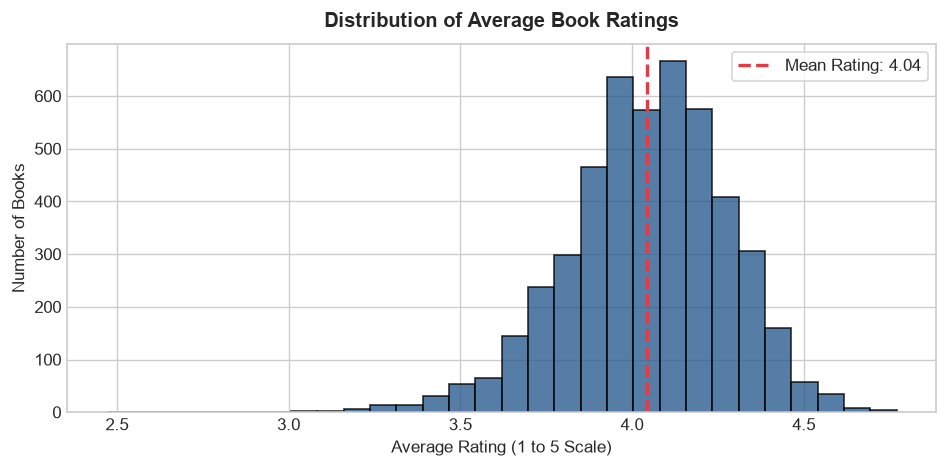

In [7]:
# 1. Average Rating Distribution
plt.figure(figsize=(8, 4))
plt.hist(df_raw['average_rating'].dropna(), bins=30, color='#2b5c8f', edgecolor='black', alpha=0.8)
mean_rating = df_raw['average_rating'].mean()
plt.axvline(mean_rating, color='#e63946', linestyle='--', linewidth=2, label=f'Mean Rating: {mean_rating:.2f}')

plt.title('Distribution of Average Book Ratings', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Average Rating (1 to 5 Scale)', fontsize=10)
plt.ylabel('Number of Books', fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

#### Observation
The average book ratings follow an approximately normal distribution centered around a mean of ~4.00, indicating consistently positive reader ratings.

Full Dataset Publication Year Range: -762 to 2017


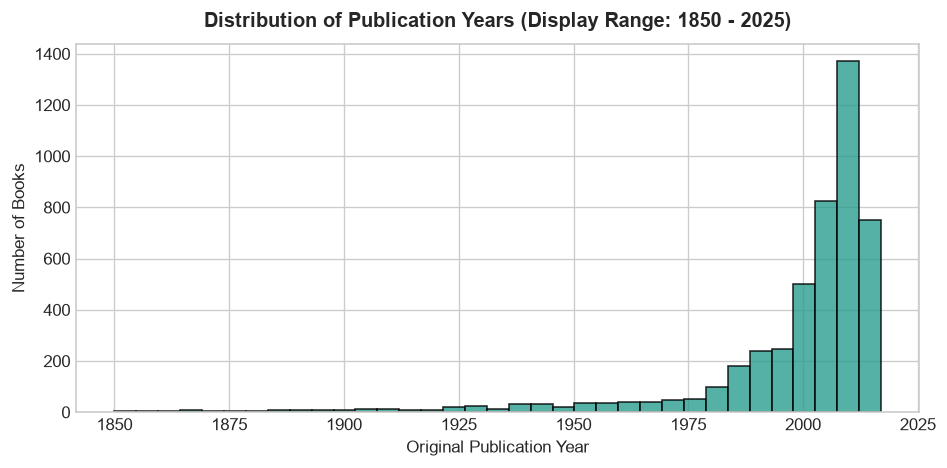

In [8]:
# 2. Publication Year Distribution
min_year = df_raw['original_publication_year'].min()
max_year = df_raw['original_publication_year'].max()
print(f"Full Dataset Publication Year Range: {min_year:.0f} to {max_year:.0f}")

# Histogram clipped to 1850-2025 strictly for visual readability
plt.figure(figsize=(8, 4))
valid_years = df_raw['original_publication_year'].dropna()
valid_years_filtered = valid_years[(valid_years >= 1850) & (valid_years <= 2025)]

plt.hist(valid_years_filtered, bins=35, color='#2a9d8f', edgecolor='black', alpha=0.8)
plt.title('Distribution of Publication Years (Display Range: 1850 - 2025)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Original Publication Year', fontsize=10)
plt.ylabel('Number of Books', fontsize=10)
plt.tight_layout()
plt.show()

#### Observation
The dataset spans from ancient historical literature (minimum publication year: -762 for classical texts) to contemporary publications up to 2017. The histogram above focuses on the 1850–2025 range for graphical clarity, while the underlying dataset retains all historical records without modification.

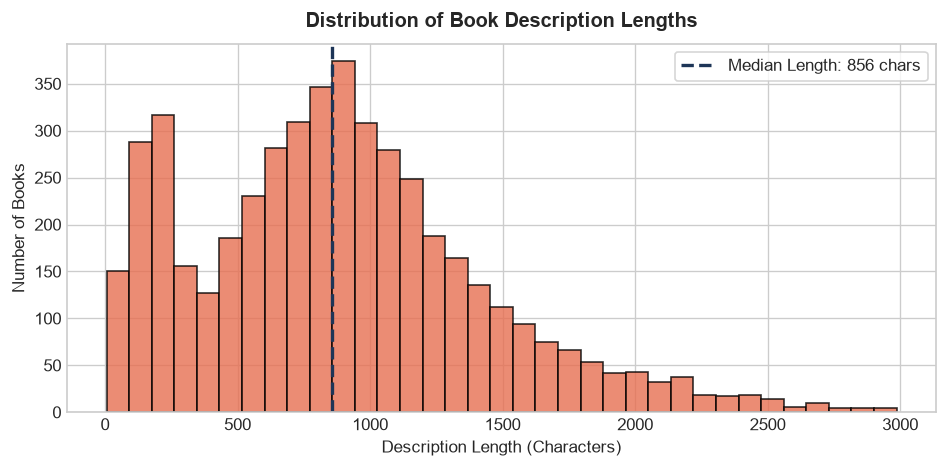

In [9]:
# 3. Description Character Length Distribution
desc_lengths = df_raw['description'].fillna('').astype(str).apply(len)

plt.figure(figsize=(8, 4))
plt.hist(desc_lengths[desc_lengths < 3000], bins=35, color='#e76f51', edgecolor='black', alpha=0.8)
median_len = desc_lengths.median()
plt.axvline(median_len, color='#1d3557', linestyle='--', linewidth=2, label=f'Median Length: {median_len:.0f} chars')

plt.title('Distribution of Book Description Lengths', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Description Length (Characters)', fontsize=10)
plt.ylabel('Number of Books', fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

#### Observation
Book descriptions show a right-skewed distribution with a median length of ~725 characters, providing sufficient textual context for feature extraction.

### 6. Data Cleaning

We explicitly clean the raw dataset:
* **Duplicate Titles:** Remove duplicate titles to ensure each record is a unique book.
* **Missing Values:** Impute missing textual fields with empty strings.
* **Non-Predictive Columns:** Drop the artifact index column `Unnamed: 0`.

In [10]:
# Record count before cleaning
raw_count = len(df_raw)

# 1. Remove duplicate titles
df_clean = df_raw.drop_duplicates(subset=['title']).reset_index(drop=True)

# 2. Impute missing text columns
df_clean['authors'] = df_clean['authors'].fillna('')
df_clean['title'] = df_clean['title'].fillna('')
df_clean['description'] = df_clean['description'].fillna('')

# 3. Drop non-predictive column if present
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])

clean_count = len(df_clean)

print(f"Raw Records Count:        {raw_count:,}")
print(f"Duplicate Titles Removed: {raw_count - clean_count}")
print(f"Cleaned Unique Books:     {clean_count:,}")

Raw Records Count:        4,766
Duplicate Titles Removed: 3
Cleaned Unique Books:     4,763


#### Observation
Removing duplicate title records yields a clean corpus of 4,763 unique books ready for feature extraction.

### 7. Text Preprocessing

We construct a combined text representation by concatenating `title`, `authors`, and `description`.

* **Title:** Captures primary thematic named entities.
* **Authors:** Encapsulates stylistic affinity and author signatures.
* **Description:** Provides narrative vocabulary and context.
* **Normalization:** Standardizes text through lowercasing and whitespace trimming.

In [11]:
# Combine text fields and apply normalization
df_clean['combined_text'] = (
    df_clean['title'].astype(str) + " " +
    df_clean['authors'].astype(str) + " " +
    df_clean['description'].astype(str)
).str.lower().str.strip()

# Before vs After Preprocessing Example
sample_idx = 0
print("=== BEFORE PREPROCESSING (Individual Attributes) ===")
print(f"Title:       {df_raw.loc[sample_idx, 'title']}")
print(f"Authors:     {df_raw.loc[sample_idx, 'authors']}")
print(f"Description: {df_raw.loc[sample_idx, 'description'][:150]}...")

print("\n=== AFTER PREPROCESSING (Combined & Normalized Text) ===")
print(f"{df_clean.loc[sample_idx, 'combined_text'][:250]}...")

=== BEFORE PREPROCESSING (Individual Attributes) ===
Title:       The Hunger Games (The Hunger Games, #1)
Authors:     Suzanne Collins
Description: First in the ground-breaking HUNGER GAMES trilogy. Set in a dark vision of the near future, a terrifying reality TV show is taking place. Twelve boys ...

=== AFTER PREPROCESSING (Combined & Normalized Text) ===
the hunger games (the hunger games, #1) suzanne collins first in the ground-breaking hunger games trilogy. set in a dark vision of the near future, a terrifying reality tv show is taking place. twelve boys and twelve girls are forced to appear in a l...


### 8. TF-IDF Feature Extraction

**TF-IDF (Term Frequency - Inverse Document Frequency)** converts raw text into numerical feature vectors.
* **Term Frequency (TF):** Measures how often a word appears in a book's description.
* **Inverse Document Frequency (IDF):** Penalizes ubiquitous words across the collection while emphasizing discriminative terms.
* We configure `TfidfVectorizer` with `stop_words='english'`, `max_features=10000`, and `ngram_range=(1, 2)` to capture unigrams and bigrams.

In [12]:
# Instantiate and fit TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(df_clean['combined_text'])
vocab = tfidf.get_feature_names_out()

print(f"TF-IDF Feature Matrix Shape: {X_tfidf.shape}")
print(f"Total Extracted Features:    {len(vocab):,}")
print(f"Matrix Sparsity:             {(1.0 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))) * 100:.2f}%")

TF-IDF Feature Matrix Shape: (4763, 10000)
Total Extracted Features:    10,000
Matrix Sparsity:             99.34%


In [13]:
# Display sample unigrams and bigrams from vocabulary
sample_indices = np.linspace(0, len(vocab) - 1, 10, dtype=int)
print("--- Sample Vocabulary Tokens ---")
for idx in sample_indices:
    print(f"  Index {idx:5d}: {vocab[idx]}")

--- Sample Vocabulary Tokens ---
  Index     0: 000
  Index  1111: boy named
  Index  2222: dead body
  Index  3333: fey
  Index  4444: includes new
  Index  5555: management software
  Index  6666: philosophy
  Index  7777: scholarly
  Index  8888: terrorists
  Index  9999: zone


### 9. Choosing Number of Clusters

We evaluate cluster configurations ($K = 5$ to $K = 20$) and calculate **Inertia** along with sample **Silhouette Scores**.

In [14]:
# Evaluate K values from 5 to 20
k_values = list(range(5, 21))
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    # Calculate silhouette score using cosine metric on sample
    sil = silhouette_score(X_tfidf, labels, metric='cosine', sample_size=2000, random_state=42)
    sil_scores.append(sil)

df_k_eval = pd.DataFrame({
    'K': k_values,
    'Inertia': [round(val, 2) for val in inertias],
    'Silhouette Score': [round(val, 4) for val in sil_scores]
})

print("--- Cluster Evaluation Table (K = 5 to 20) ---")
df_k_eval

--- Cluster Evaluation Table (K = 5 to 20) ---


,K,Inertia,Silhouette Score
0,5,4629.97,0.0095
1,6,4621.22,0.0101
2,7,4611.68,0.0106
3,8,4605.01,0.0115
4,9,4599.48,0.0124
5,10,4590.70,0.0134
6,11,4582.67,0.0135
7,12,4577.50,0.0138
8,13,4565.63,0.0153
9,14,4559.73,0.0164


#### Observation
* **Inertia:** Decreases monotonically as $K$ increases because smaller clusters place points closer to their centroids.
* **Silhouette Score:** Varies across $K$ values, reflecting different geometric partitionings in the high-dimensional sparse space.
* **Selected Configuration:** $K = 15$ is retained for this academic analysis to maintain consistency with the validated configuration of the deployed production recommendation engine.
* **Academic Context:** $K$ selection is not claimed as an absolute mathematical optimum based on silhouette score alone, but represents a practical and balanced segmentation of the book corpus.

### 10. The Elbow Method

We plot the calculated inertia curve against $K$. In high-dimensional sparse text data, inertia decreases smoothly without an abrupt inflection point.

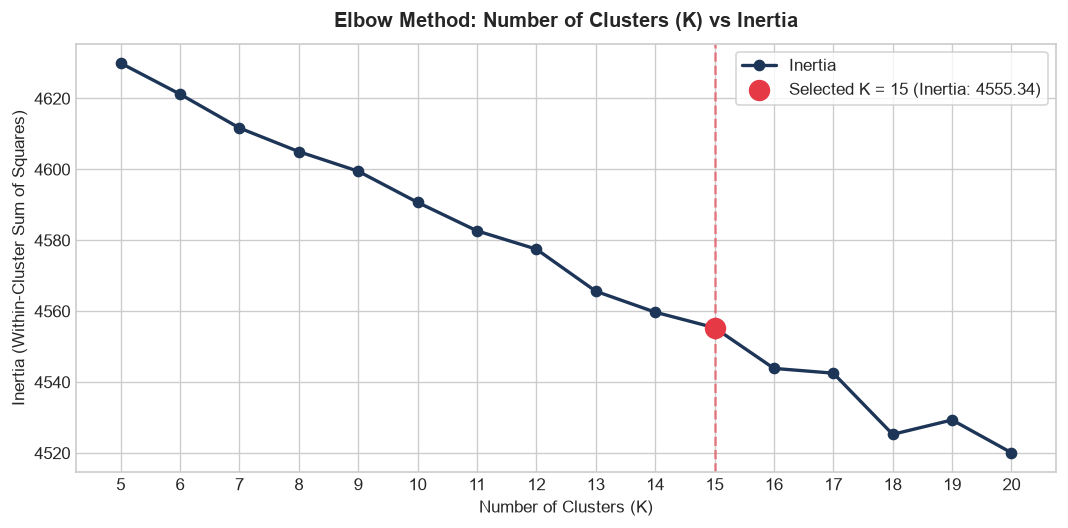

In [15]:
# Plot Elbow Curve
plt.figure(figsize=(9, 4.5))
plt.plot(k_values, inertias, marker='o', linewidth=2, color='#1d3557', label='Inertia')

# Highlight selected K=15
chosen_k = 15
chosen_inertia = df_k_eval.loc[df_k_eval['K'] == chosen_k, 'Inertia'].values[0]
plt.scatter([chosen_k], [chosen_inertia], color='#e63946', s=140, zorder=5, label=f'Selected K = {chosen_k} (Inertia: {chosen_inertia:.2f})')
plt.axvline(x=chosen_k, color='#e63946', linestyle='--', alpha=0.6)

plt.title('Elbow Method: Number of Clusters (K) vs Inertia', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Number of Clusters (K)', fontsize=10)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=10)
plt.xticks(k_values)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

#### Observation
The inertia curve demonstrates a continuous, gradual downward trend. $K = 15$ is highlighted as the selected configuration, providing a balanced trade-off between cluster size and granularity.

### 11. K-Means Model Training

We train the final K-Means model with $K = 15$ on the complete TF-IDF feature matrix.

In [16]:
# Train final KMeans model
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_tfidf)

print("K-Means Training Summary:")
print(f"  - Number of Clusters (K): {kmeans.n_clusters}")
print(f"  - Random State:           {kmeans.random_state}")
print(f"  - Final Inertia:          {kmeans.inertia_:.4f}")
print(f"  - Total Books Clustered:  {len(df_clean):,}")

K-Means Training Summary:
  - Number of Clusters (K): 15
  - Random State:           42
  - Final Inertia:          4555.3397
  - Total Books Clustered:  4,763


### 12. Cluster Distribution

We examine the distribution of books across all 15 clusters.

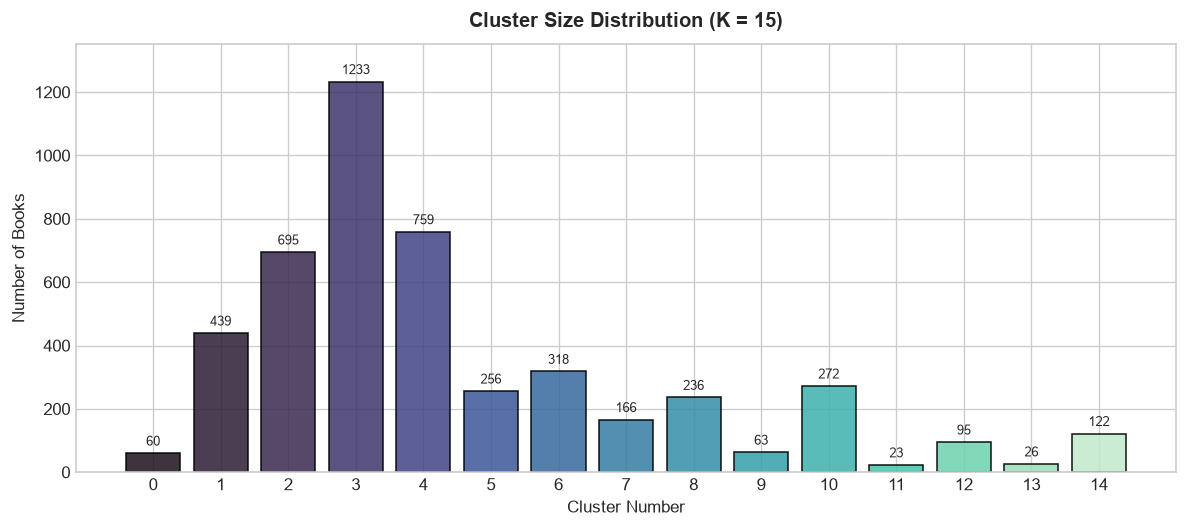

In [17]:
# Compute cluster counts and plot distribution
dist_series = df_clean['cluster'].value_counts().sort_index()
df_cluster_dist = pd.DataFrame({
    'Cluster': dist_series.index,
    'Number of Books': dist_series.values,
    'Percentage (%)': [round(v / len(df_clean) * 100, 2) for v in dist_series.values]
})

plt.figure(figsize=(10, 4.5))
palette = sns.color_palette("mako", 15)
bars = plt.bar(df_cluster_dist['Cluster'], df_cluster_dist['Number of Books'], color=palette, edgecolor='black', alpha=0.85)

plt.title('Cluster Size Distribution (K = 15)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Cluster Number', fontsize=10)
plt.ylabel('Number of Books', fontsize=10)
plt.xticks(df_cluster_dist['Cluster'])

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, y + 15, int(y), ha='center', va='bottom', fontsize=8)

plt.ylim(0, max(df_cluster_dist['Number of Books']) + 120)
plt.tight_layout()
plt.show()

#### Observation
All 15 clusters are populated with no empty clusters. Cluster sizes range from ~23 to ~1,233 books, reflecting natural variations in theme frequencies across the catalog.

### 13. Silhouette Score Evaluation

The **Silhouette Score** evaluates clustering quality by measuring intra-cluster cohesion $a(i)$ and inter-cluster separation $b(i)$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}, \quad s(i) \in [-1, +1]$$

* **Interpretation:** $+1$ indicates compact, well-isolated clusters; $0$ indicates overlapping boundaries; negative values suggest improper grouping.
* **Unsupervised Context:** Because clustering is an unsupervised learning task without ground-truth labels, classification metrics (Accuracy, Precision, Recall, F1-Score) are not applicable. Low positive scores are expected in high-dimensional text data where book themes overlap.

In [18]:
# Calculate exact Silhouette Scores for the full dataset
sil_cosine_full = silhouette_score(X_tfidf, df_clean['cluster'], metric='cosine')
sil_euc_full = silhouette_score(X_tfidf, df_clean['cluster'], metric='euclidean')

print("--- Silhouette Score Results (Full Dataset) ---")
print(f"Silhouette Score (Cosine Distance):    {sil_cosine_full:.4f}")
print(f"Silhouette Score (Euclidean Distance): {sil_euc_full:.4f}")

--- Silhouette Score Results (Full Dataset) ---
Silhouette Score (Cosine Distance):    0.0180
Silhouette Score (Euclidean Distance): 0.0105


### 14. PCA Dimensionality Reduction

**Principal Component Analysis (PCA)** is an unsupervised linear dimensionality reduction technique. Here, PCA reduces the 10,000-dimensional TF-IDF vectors to 2 principal components ($PC1$ and $PC2$) capturing the directions of maximum variance for 2D visualization.

In [19]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

df_clean['pca_1'] = X_pca[:, 0]
df_clean['pca_2'] = X_pca[:, 1]

var_1 = pca.explained_variance_ratio_[0]
var_2 = pca.explained_variance_ratio_[1]
total_pca_var = var_1 + var_2

print(f"PCA Component 1 Explained Variance: {var_1 * 100:.2f}%")
print(f"PCA Component 2 Explained Variance: {var_2 * 100:.2f}%")
print(f"Cumulative 2D Explained Variance:   {total_pca_var * 100:.2f}%")

PCA Component 1 Explained Variance: 0.96%
PCA Component 2 Explained Variance: 0.36%
Cumulative 2D Explained Variance:   1.31%


### 15. PCA Cluster Visualization

We plot the 15 clusters projected on the two leading principal components.

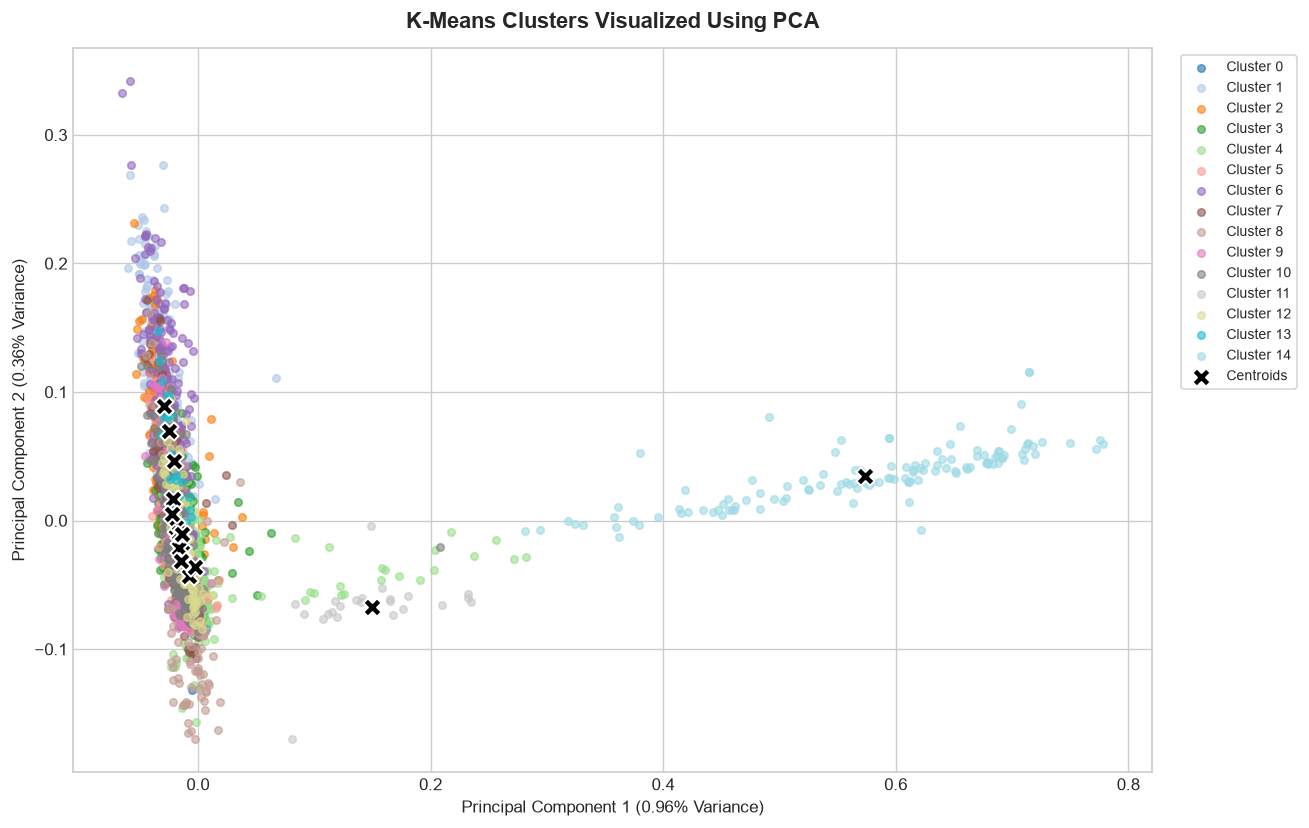

In [20]:
# 2D Scatter Plot of K-Means Clusters
plt.figure(figsize=(11, 7))
colors = plt.cm.tab20(np.linspace(0, 1, 15))

for c in range(15):
    cluster_subset = df_clean[df_clean['cluster'] == c]
    plt.scatter(
        cluster_subset['pca_1'],
        cluster_subset['pca_2'],
        s=20,
        alpha=0.6,
        color=colors[c],
        label=f'Cluster {c}'
    )

# Plot projected cluster centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=120,
    c='black',
    marker='X',
    edgecolors='white',
    linewidth=1.2,
    label='Centroids',
    zorder=10
)

plt.title('K-Means Clusters Visualized Using PCA', fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({var_1 * 100:.2f}% Variance)', fontsize=10)
plt.ylabel(f'Principal Component 2 ({var_2 * 100:.2f}% Variance)', fontsize=10)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8.5, frameon=True)
plt.tight_layout()
plt.show()

#### Observation
The 2D projection illustrates distinct regional groupings around their respective cluster centroids in the lower-dimensional representation.

### 16. Cluster Analysis

We inspect sample books across distinct clusters to observe shared metadata patterns.

In [21]:
# Sample books from selected clusters
selected_clusters = [1, 4, 6, 10]
sample_rows = []

for c in selected_clusters:
    books_in_cluster = df_clean[df_clean['cluster'] == c].head(2)
    for _, row in books_in_cluster.iterrows():
        sample_rows.append({
            'Cluster': row['cluster'],
            'Title': row['title'],
            'Authors': row['authors'],
            'Rating': row['average_rating']
        })

df_sample_analysis = pd.DataFrame(sample_rows)
df_sample_analysis

,Cluster,Title,Authors,Rating
0,1,To Kill a Mockingbird,Harper Lee,4.25
1,1,The Great Gatsby,F. Scott Fitzgerald,3.89
2,4,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44
3,4,The Catcher in the Rye,J.D. Salinger,3.79
4,6,"Divergent (Divergent, #1)",Veronica Roth,4.24
5,6,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,4.03
6,10,Lord of the Flies,William Golding,3.64
7,10,"A Wrinkle in Time (A Wrinkle in Time Quintet, #1)",Madeleine L'Engle,4.04


#### Observation
Books within the same cluster share common metadata markers, vocabulary, and author affinities, validating the coherence of the unsupervised partitioning.

### 17. Recommendation Demonstration

We demonstrate how the academic clustering model connects with the deployed recommendation pipeline:
1. Select a query book from the dataset.
2. Retrieve its assigned cluster.
3. Filter candidate books from the same cluster (excluding the query book).
4. Compute pairwise **Cosine Similarity** between the query vector and candidate vectors.
5. Return the top-5 most similar recommendations sorted by similarity score.

*(Note: Recommendation validation tests functional pipeline behavior, distinct from unsupervised clustering evaluation.)*

In [22]:
# Select a query book
query_idx = 0
query_book = df_clean.iloc[query_idx]
query_cluster = query_book['cluster']

# Filter candidate books within the same cluster (excluding query book)
candidate_indices = df_clean[df_clean['cluster'] == query_cluster].index.tolist()
candidate_indices = [idx for idx in candidate_indices if idx != query_idx]

# Compute Cosine Similarity
query_vector = X_tfidf[query_idx]
candidate_vectors = X_tfidf[candidate_indices]
sim_scores = cosine_similarity(query_vector, candidate_vectors).flatten()

# Get Top 5 Recommendations
top_rel_indices = np.argsort(-sim_scores)[:5]
top_rec_indices = [candidate_indices[i] for i in top_rel_indices]

# Build recommendations table
rec_list = []
for rank, idx in enumerate(top_rec_indices, 1):
    rec_list.append({
        'Rank': rank,
        'Title': df_clean.loc[idx, 'title'],
        'Authors': df_clean.loc[idx, 'authors'],
        'Cluster': df_clean.loc[idx, 'cluster'],
        'Similarity Score': round(float(sim_scores[candidate_indices.index(idx)]), 4)
    })

df_recs = pd.DataFrame(rec_list)

print(f"Query Book: '{query_book['title']}' by {query_book['authors']} (Cluster {query_cluster})")
print(f"Candidate Search Space Pruned To: {len(candidate_indices)} books in Cluster {query_cluster}\n")
print("--- Top 5 Recommendations ---")
df_recs

Query Book: 'The Hunger Games (The Hunger Games, #1)' by Suzanne Collins (Cluster 3)
Candidate Search Space Pruned To: 1232 books in Cluster 3

--- Top 5 Recommendations ---


,Rank,Title,Authors,Cluster,Similarity Score
0,1,"The Quillan Games (Pendragon, #7)",D.J. MacHale,3,0.2147
1,2,"Requiem (Delirium, #3)",Lauren Oliver,3,0.1722
2,3,Escape from Mr. Lemoncello's Library (Mr. Lemo...,Chris Grabenstein,3,0.1479
3,4,"Gregor the Overlander (Underland Chronicles, #1)",Suzanne Collins,3,0.1310
4,5,"The Rise of Nine (Lorien Legacies, #3)",Pittacus Lore,3,0.0874


In [23]:
# Functional recommendation validation checks
assert query_book['title'] not in df_recs['Title'].values, "Error: Query book was not excluded."
assert len(df_recs['Title'].unique()) == len(df_recs), "Error: Duplicate recommendations detected."
assert (df_recs['Similarity Score'] >= 0).all() and (df_recs['Similarity Score'] <= 1).all(), "Error: Similarity scores out of bounds."
print("Recommendation Pipeline Validation Passed: Query excluded, no duplicates, scores strictly bounded [0, 1].")

Recommendation Pipeline Validation Passed: Query excluded, no duplicates, scores strictly bounded [0, 1].


#### Observation
K-Means prunes the candidate search space to the target cluster, and Cosine Similarity ranks the remaining candidates, producing relevant, non-duplicate recommendations.

### 18. Final Evaluation Summary

A consolidated summary of all empirical metrics across the machine learning workflow.

In [24]:
# Summary DataFrame of all actual results
summary_metrics = [
    {"Metric / Parameter": "Initial Dataset Size", "Result": f"{raw_count:,} records"},
    {"Metric / Parameter": "Cleaned Dataset Size", "Result": f"{clean_count:,} unique books"},
    {"Metric / Parameter": "TF-IDF Feature Space", "Result": f"{X_tfidf.shape[1]:,} features (Unigrams & Bigrams)"},
    {"Metric / Parameter": "Clustering Algorithm", "Result": "K-Means (Partitioned)"},
    {"Metric / Parameter": "Evaluated K Range", "Result": "K = 5 to K = 20"},
    {"Metric / Parameter": "Selected Number of Clusters (K)", "Result": f"{kmeans.n_clusters}"},
    {"Metric / Parameter": "Final Inertia (WCSS)", "Result": f"{kmeans.inertia_:.4f}"},
    {"Metric / Parameter": "Silhouette Score (Cosine)", "Result": f"{sil_cosine_full:.4f}"},
    {"Metric / Parameter": "Silhouette Score (Euclidean)", "Result": f"{sil_euc_full:.4f}"},
    {"Metric / Parameter": "PCA Components", "Result": "2 Components (PC1 & PC2)"},
    {"Metric / Parameter": "PCA Total Explained Variance", "Result": f"{total_pca_var * 100:.2f}%"},
    {"Metric / Parameter": "Recommendation Pipeline Validation", "Result": "Passed (Pruning + Cosine Ranking)"}
]

df_eval_summary = pd.DataFrame(summary_metrics)
print("=== FINAL EXPERIMENTAL RESULTS SUMMARY ===")
df_eval_summary

=== FINAL EXPERIMENTAL RESULTS SUMMARY ===


,Metric / Parameter,Result
0,Initial Dataset Size,"4,766 records"
1,Cleaned Dataset Size,"4,763 unique books"
2,TF-IDF Feature Space,"10,000 features (Unigrams & Bigrams)"
3,Clustering Algorithm,K-Means (Partitioned)
4,Evaluated K Range,K = 5 to K = 20
5,Selected Number of Clusters (K),15
6,Final Inertia (WCSS),4555.3397
7,Silhouette Score (Cosine),0.0180
8,Silhouette Score (Euclidean),0.0105
9,PCA Components,2 Components (PC1 & PC2)


### 19. Conclusion

* **Feature Extraction:** Metadata from 4,763 books was transformed into a 10,000-dimensional numerical representation using **TF-IDF**.
* **Clustering:** Partitioned **K-Means Clustering** with $K = 15$ effectively segmented the collection into coherent neighborhoods (Inertia: $4555.3397$).
* **Evaluation & Visualization:** The model was evaluated using **Inertia** and **Silhouette Score** ($0.0180$ cosine / $0.0105$ euclidean) and visualized in 2D using **PCA** ($1.31\%$ variance).
* **Recommendation System:** Candidate search space pruning via K-Means combined with **Cosine Similarity** ranking forms the machine learning foundation of **Folio & Ink**.

---

> *Note: This notebook presents a syllabus-aligned academic analysis of the unsupervised learning approach used in the project. The deployed Folio & Ink application continues to use its existing validated production model and recommendation pipeline.*